# Hands-on: the operating rule, defended

**Week 2, Friday. The second case.** A director wants to edit the source in the room. This
notebook plays it out on the tree: the edit, the check that catches it, the refresh that wipes it, and
where the director's assumption belongs. Four lettered `TODO` markers; each answer is the letter
itself, as a string. This is the executed solution.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

clean = pd.read_csv(kit.data_dir() / "C2_W02_D05_customer_table_STUDENT.csv")
raw = pd.read_csv(kit.data_dir() / "C2_W02_D05_raw_export_STUDENT.csv")
WAREHOUSE = {"Q1": 100_000_000, "Q2": 98_400_000}   # Monday's warehouse totals, from Week 2 Monday
SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]


def crore(n):
    return f"Rs {n / 1e7:.2f} crore"


def lakh(n):
    return f"Rs {n / 1e5:.2f} lakh"


print(len(clean), "customer rows and", len(raw), "export rows loaded")

raw["quarter"] = pd.to_datetime(raw.order_date).dt.month.map(lambda m: "Q1" if m <= 6 else "Q2")
orders = raw.drop_duplicates("order_id")

300 customer rows and 1450 export rows loaded


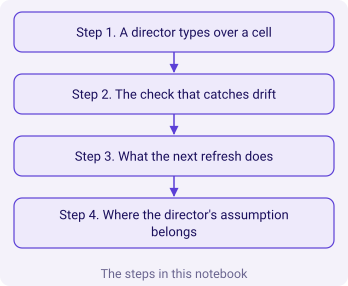

In [2]:
kit.vflow(['Step 1. A director types over a cell', 'Step 2. The check that catches drift', 'Step 3. What the next refresh does', "Step 4. Where the director's assumption belongs"], title='The steps in this notebook')

## Step 1. A director types over a cell

In the room, a director overwrites Retail-Plus Q2 revenue in the tree with the Rs 5,00,000 he expects
next quarter, so the card looks better. The sheet recalculates.

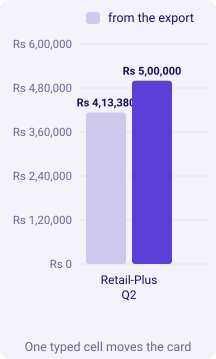

In [3]:
sheet = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
edited = sheet.copy()
edited.loc["Retail-Plus", "Q2"] = 500000
# TODO 1. Which number does the edited card now show for Retail-Plus, Q1 to Q2?
#   a) the true change, since the source did not move
#   b) the edited change, computed from the typed value
#   c) an error, since a typed value breaks the formula
#   d) no change, since Q1 was not edited
shown = "b"
kit.columns(["Retail-Plus Q2"], [("from the export", [int(sheet.loc["Retail-Plus", "Q2"])]),
                                  ("after the edit", [int(edited.loc["Retail-Plus", "Q2"])])],
            fmt=kit.rupees, title="One typed cell moves the card")

In [4]:
kit.check("the edited card shows a smaller fall", shown == "b" and
          edited.loc["Retail-Plus", "Q2"] > sheet.loc["Retail-Plus", "Q2"])
kit.check("the edit leaves no trace in the source", int(orders.order_amount.sum()) == sum(WAREHOUSE.values()))

**Why the other letters fail.** The card recomputes from whatever sits in the cell, so it shows a fall of 14.6 percent where the export says 29.4. a assumes the sheet reads the source; it reads the cell. c is what people hope; a typed number is a valid input. d ignores that the change uses Q2.

## Step 2. The check that catches drift

A drift check compares the sheet with the source of truth. Pick the comparison that fires here.

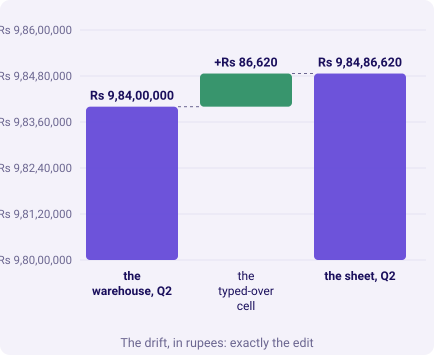

In [5]:
# TODO 2. Which comparison catches the director's edit?
#   a) the sheet's Q2 total against the warehouse's Q2 total
#   b) the sheet's number of segments against four
#   c) the Q1 column against the warehouse's Q1
#   d) the card's sentence against yesterday's sentence
drift = {"a": int(edited.Q2.sum()) - WAREHOUSE["Q2"], "b": len(edited) - 4,
         "c": int(edited.Q1.sum()) - WAREHOUSE["Q1"], "d": 0}["a"]
kit.bridge(("the warehouse, Q2", WAREHOUSE["Q2"]), [("the typed-over cell", int(drift))],
           end_label="the sheet, Q2", fmt=kit.rupees, lo=98_000_000,
           title="The drift, in rupees: exactly the edit")

In [6]:
kit.check("the drift check fires", drift != 0, kit.rupees(drift))
kit.check("the drift equals the edit", drift == 500000 - int(sheet.loc["Retail-Plus", "Q2"]))

**Why the other letters fail.** b counts rows, which an edit never changes. c looks at the quarter nobody touched. d compares wording, which moves whenever anybody improves a sentence.

## Step 3. What the next refresh does

On Monday the tree is rebuilt from a fresh export.

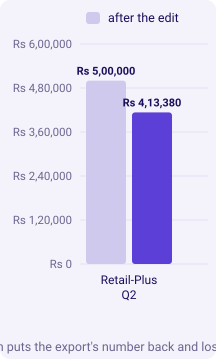

In [7]:
refreshed = orders.pivot_table(index="segment", columns="quarter", values="order_amount", aggfunc="sum")
# TODO 3. After the refresh, what happened to the director's number?
#   a) it survived, since Excel keeps typed values
#   b) it moved into the warehouse
#   c) it doubled, since the export has two rows per payment
#   d) it was wiped without a trace, and so was its reason
after = "d"
kit.columns(["Retail-Plus Q2"], [("after the edit", [int(edited.loc["Retail-Plus", "Q2"])]),
                                  ("after the refresh", [int(refreshed.loc["Retail-Plus", "Q2"])])],
            fmt=kit.rupees, title="The refresh puts the export's number back and loses the edit")

In [8]:
kit.check("the refresh restores the export's number", refreshed.loc["Retail-Plus", "Q2"] == sheet.loc["Retail-Plus", "Q2"])
kit.check("the refreshed sheet reconciles again", int(refreshed.values.sum()) == sum(WAREHOUSE.values()) and after == "d")

**Why the other letters fail.** a is the drift the rule exists to stop: a typed value that survives a refresh is a second source of truth. b never happens; the warehouse does not read the sheet. c confuses the refresh with round 1's grain.

## Step 4. Where the director's assumption belongs

The director's expectation is a real question: what would the card say if Retail-Plus recovered to
Rs 5,00,000? It belongs in the sheet, as an input beside the source, never over it.

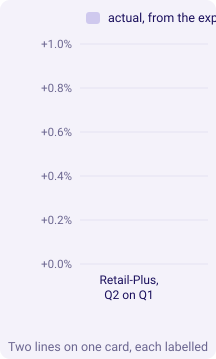

In [9]:
# TODO 4. Where does the what-if go?
#   a) over the Q2 cell, with a comment saying it was edited
#   b) in a yellow input cell, feeding a separate scenario line on the card
#   c) in the export, before it is loaded
#   d) nowhere; directors do not get what-ifs
scenario_q2 = 500000
place = "b"
actual = sheet.loc["Retail-Plus", "Q2"] / sheet.loc["Retail-Plus", "Q1"] - 1
what_if = scenario_q2 / sheet.loc["Retail-Plus", "Q1"] - 1
kit.columns(["Retail-Plus, Q2 on Q1"], [("actual, from the export", [round(actual * 100, 1)]),
                                         ("the director's scenario", [round(what_if * 100, 1)])],
            fmt=lambda v: f"{v:+.1f}%", title="Two lines on one card, each labelled")

In [10]:
kit.check("the actual line still reconciles", int(sheet.values.sum()) == sum(WAREHOUSE.values()))
kit.check("the scenario is labelled and separate", place == "b" and round(what_if * 100, 1) == -14.6, f"{what_if:.1%}")

**Why the other letters fail.** a keeps the edit and adds a note nobody reads on a projector. c edits the source of truth, which is the thing the rule forbids. d refuses a legitimate question and sends the director to type over cells anyway.

**Post.** Your four letters in order, as one line, then the one rule you would put on the sheet's
Start tab. The key is `badb`.

In [11]:
kit.check_summary()